
# **TMS 2025 AI Workshop: Ryan Jacobs, Ben Afflerbach, Dane Morgan (UW-Madison)**

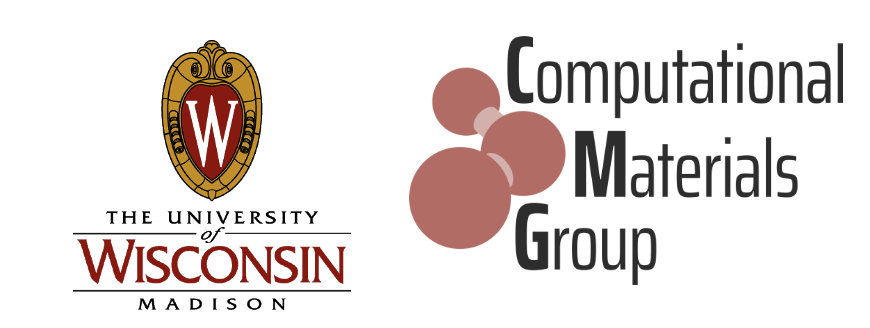

---


## Google Colab notebook demo of structure based property prediction:
## Trainging for prediction Na-battery material voltage

# Part 1: Installation and setup

To begin, we need to install needed python dependencies to run [ALIGNN](https://github.com/usnistgov/alignn)

We'll checkout and install a slightly older branch of the code that is compatible with the current Google Colab Environment

In [ ]:
%%time
import os
os.chdir('/content')
# Clone ALIGNN repo to get example folder
if not os.path.exists('alignn'):
   !git clone https://github.com/atomgptlab/alignn.git
os.chdir("alignn")

!git checkout v2024.12.12
!pip install -q --no-cache-dir dgl -f https://data.dgl.ai/wheels/torch-2.4/cu124/repo.html
!pip install -e .
os.chdir('/content')

In [ ]:
!pip install pymatgen mp_api

Double check that we have the ALIGNN code with example dataset

In [ ]:
import os
!pwd
os.chdir('/content')
# Clone ALIGNN repo to get example folder
if not os.path.exists('alignn'):
  !git clone https://github.com/usnistgov/alignn.git

os.chdir('alignn')

# Part 2: Training and Predicting using sample POSCAR data

ALIGNN github package comes with an example dataset. let's do a quick test with that to check things are working and installed correctly

The example data we'll work with is configured as a directory of POSCAR files. Additionally it must contain a file "id_prop.csv" which is a two two column csv with file names matching the POSCAR files paired with the property value of interest. The example dataset is a set of Band Gap values.

In [ ]:
!ls "alignn/examples/sample_data"

sample structure of the id_prop.csv file

In [ ]:
!head "alignn/examples/sample_data/id_prop.csv"

The last file in the sample data folder is config_example.json

This configuration file sets various aspects of the dataset from model architecture details, to training parameters.

To interact with it I'll suggest double clicking from the file explorer on the left of the Google Colab interface to inspect and view directly rather than reading in the json file to Python

To perform a training run we'll use the train_alignn.py script. Any configuration tags specified in the call will overwrite the defaults in the config file.

In [ ]:
!train_alignn.py --root_dir "alignn/examples/sample_data" \
                 --epochs 100 \
                 --batch_size 4 \
                 --config "alignn/examples/sample_data/config_example.json" \
                 --output_dir="sample_test"

In [ ]:
!ls

To use the trainined model we can load model checkpoints from the output directory

In [ ]:
import torch
from alignn.models.alignn_atomwise import ALIGNNAtomWise , ALIGNNAtomWiseConfig

output_directory = 'sample_test/'
output_features =  1
filename = os.path.join(output_directory,'best_model.pt')
device = "cpu"
if torch.cuda.is_available():
    device = torch.device("cuda")

from jarvis.db.jsonutils import loadjson
# load config from output folder
config=loadjson(os.path.join(output_directory,'config.json'))

model = ALIGNNAtomWise(ALIGNNAtomWiseConfig(**config["model"]))
model.load_state_dict(torch.load(filename, map_location=device))
model.eval()

To make predictions we load a POSCAR file and build a graph representation

In [ ]:
from jarvis.core.atoms import Atoms
from alignn.graphs import Graph
cutoff = 8.0
model=model.to(device)
max_neighbors = 12
# pick one of the sample data files for this quick demo
atoms = Atoms.from_poscar('alignn/examples/sample_data/POSCAR-JVASP-10.vasp')
g, lg = Graph.atom_dgl_multigraph(atoms, cutoff=float(cutoff), max_neighbors=max_neighbors)
lat = torch.tensor(atoms.lattice_mat)
out_data = (
    model([g.to(device), lg.to(device),lat.to(device)])['out']
    .detach()
    .cpu()
    .numpy()
    .flatten()
    .tolist()[0]
)

print ('output: ', out_data)

With the small training dataset the example model is clearly giving some unphysical values for bandgaps, but at least shows that the training scripts are working without error.

We can also modify structures, rebuild the graph, and update predictions. In this case we make a supercell of the previous structure

In [ ]:
atoms = atoms.make_supercell([2, 2, 2])
g, lg = Graph.atom_dgl_multigraph(atoms)
lat = torch.tensor(atoms.lattice_mat)
out_data = (
    model([g.to(device), lg.to(device),lat.to(device)])['out']
    .detach()
    .cpu()
    .numpy()
    .flatten()
    .tolist()[0]
)
print("supercell", out_data)

In addition to individual structures, let's look at the model performance across the test dataset

In [ ]:
from jarvis.db.jsonutils import loadjson
import pandas as pd

d=loadjson(os.path.join(output_directory,'Test_results.json'))
x=[i['target_out'][0] for i in d]
y=[i['pred_out'] for i in d]
ids=[i['id'] for i in d]

we can convert to csv for later

In [ ]:
# Create a DataFrame to save the results in csv for later
data = {'id': ids, 'target': x, 'prediction': y}
temp_df = pd.DataFrame(data)

# Save the DataFrame as a CSV file
csv_file = 'sample_test/prediction_results_test_set.csv'
temp_df.to_csv(csv_file, index=False)

In [ ]:
import matplotlib.pyplot as plt
plt.plot(x,y,'.')
plt.plot(x,x)
plt.xlabel('DFT')
plt.ylabel('ALIGNN')

from sklearn.metrics import mean_absolute_error
print('MAE',mean_absolute_error(x,y))

Here we can see more directly the model hasn't captured the output values well at all due to limited training data.

In [ ]:
df

# Part 3: Obtaining Voltage Data

The data file contains U-MLIP relaxed structures and average voltages for 2288 materials. Let's plot a histogram of the computed average voltages to see their distribution:

In [ ]:
import joblib
import pandas as pd
import numpy as np
import os
from pymatgen.core import Structure, Composition
import matplotlib.pyplot as plt

import sys

We'll mount google drive and make sure to have setup a shortcut to the "TMS_2025_AI_workshop" folder to get default path names to work.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

if you have some other file structure make sure to change the path name below. We are loading in a pre-configured pickled file of Na battery voltage predictions including pymatgen structure objects.

In [ ]:
d = '/content/drive/MyDrive/TMS AI4MSE for DEMO 2025-10-28/Sec 2 ALIGNN'
df = joblib.load(os.path.join(d, 'mp_Na_eqV2.pkl'))

df.head()

In [ ]:
def plot_voltage_histogram(df, dataset='MP', ion='Na'):
    bins = np.arange(0, 10, 0.2)

    # Matterverse avg voltage has a bunch of negative values- remove them!
    df = df[df['Average voltage (V/ion)'] >=0]

    plt.clf()

    plt.hist(bins=bins, x=df['Average voltage (V/ion)'], color='red', edgecolor='black', alpha=0.5, label='EquiformerV2')

    plt.xlabel('Average voltage (V/Na)', fontsize=14)
    plt.xticks(fontsize=12)
    plt.ylabel('Number of occurrences', fontsize=14)
    plt.yticks(fontsize=12)
    plt.legend(loc='best')
    plt.savefig('Voltage_histogram_'+dataset+'_'+ion+'.png', dpi=300, bbox_inches='tight')

    vals = df['Average voltage (V/ion)']
    print('EquiformerV2 stats')
    print(np.mean(vals), np.std(vals), min(vals), max(vals))

    return

In [ ]:
plot_voltage_histogram(df)

# Part 4: Creating the input data structure


ALIGNN expects a set of input POSCAR files so let's create a new directory and output all 2,288 structures to POSCAR files

In [ ]:
import os

# Create the directory if it doesn't exist
output_dir = 'voltage_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Create a list to store the filenames
filenames = []

# Iterate through the DataFrame and save each structure as a POSCAR file
for i, structure in enumerate(df['Structure']):
    filename = f'POSCAR_{i}.vasp'
    structure.to(os.path.join(output_dir,filename))
    filenames.append(filename)

# Add the filenames as a new column to the DataFrame
df['poscar_filename'] = filenames

print(f"Saved {len(df)} POSCAR files to the '{output_dir}' directory and added filenames to the DataFrame.")

And use the previous dataframe to create our id_prop.csv

In [ ]:
output_file = os.path.join(output_dir, 'id_prop.csv')

# Select the required columns and save to a CSV file without headers
df[['poscar_filename', 'Average voltage (V/ion)']].to_csv(output_file, index=False, header=False)

print(f"Saved id and property data to '{output_file}'.")

The first column points to each POSCAR file we created, and the second the paired Average Voltage property

In [ ]:
!head 'voltage_data/id_prop.csv'

To start we'll use the same example config file

In [ ]:
import os
import shutil

source_config_path = 'alignn/examples/sample_data/config_example.json'
destination_config_path = 'voltage_data/config.json'

# Ensure the destination directory exists (already created in a previous step)
output_dir = 'voltage_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Copy the config file
shutil.copyfile(source_config_path, destination_config_path)

print(f"Copied '{source_config_path}' to '{destination_config_path}'")

In [ ]:
from jarvis.db.jsonutils import loadjson
# import os

config_path = 'voltage_data/config.json'
config = loadjson(config_path)
print("Config file loaded successfully.")

And we'll make sure to update the 'filename' key which is a filename for where the constructed graphs of each structure will be cached. If we don't update this ALIGNN will continue to pull the previous structuers instead of our new ones. Anytime we want to update structures we need to make sure to clear this out or change the setting.

In [ ]:
from jarvis.db.jsonutils import dumpjson

config['filename'] = 'V'
print("Updated config['filename'] to:", config['filename'])

config_path = 'voltage_data/config.json'
dumpjson(config,config_path)
print(f"Updated config saved to '{config_path}'")

# Part 5: Creating a Na voltage property predictor

with these setting on a T4 each epoch takes ~1 minute  
10 epochs is expected to take ~10 minutes in the example below

In [ ]:
!train_alignn.py --root_dir 'voltage_data' \
                --epochs 10 \
                --batch_size 16 \
                --config './voltage_data/config.json' \
                --output_dir=voltage_output


Let's visualize the performance

In [ ]:
import torch
from alignn.models.alignn_atomwise import ALIGNNAtomWise , ALIGNNAtomWiseConfig
output_features =  1
filename = 'voltage_output/best_model.pt'
device = "cpu"
if torch.cuda.is_available():
    device = torch.device("cuda")

from jarvis.db.jsonutils import loadjson
# load config from output folder
config=loadjson('voltage_output/config.json')

model = ALIGNNAtomWise(ALIGNNAtomWiseConfig(**config["model"]))
model.load_state_dict(torch.load(filename, map_location=device))
model.eval()

again load back in the test data

In [ ]:
d=loadjson('voltage_output/Test_results.json')
x=[i['target_out'][0] for i in d]
y=[i['pred_out'] for i in d]
ids=[i['id'] for i in d]

In [ ]:
# Create a DataFrame
data = {'id': ids, 'target': x, 'prediction': y}
voltage_df = pd.DataFrame(data)

# Save the DataFrame as a CSV file
csv_file = 'voltage_output/prediction_results_test_set.csv'
voltage_df.to_csv(csv_file, index=False)

In [ ]:
voltage_df.head()

In [ ]:
import matplotlib.pyplot as plt
plt.plot(x,y,'.')
plt.plot(x,x)
plt.xlabel('eqV2')
plt.ylabel('ALIGNN')

from sklearn.metrics import mean_absolute_error
print('MAE',mean_absolute_error(x,y))

NOTE: Running for 100 epochs yielded MAE of 0.189

# Part 6:  Investigate a particular structure

Let's build the graph for one of our structures and highlight a more in depth check we might do.

In [ ]:
from jarvis.core.atoms import Atoms
from alignn.graphs import Graph
cutoff = 8.0
model=model.to(device)
max_neighbors = 12
# pick one of the sample data files for this
atoms = Atoms.from_poscar('voltage_data/POSCAR_0.vasp')

We'll read back in a Manganese Oxide structure.

In [ ]:
atoms

In [ ]:
g, lg = Graph.atom_dgl_multigraph(atoms, cutoff=float(cutoff), max_neighbors=max_neighbors)
lat = torch.tensor(atoms.lattice_mat)
out_data = (
    model([g.to(device), lg.to(device),lat.to(device)])['out']
    .detach()
    .cpu()
    .numpy()
    .flatten()
    .tolist()[0]
)

print ('predicted Average Voltage (V/ion): ', round(out_data,3))

In [ ]:
print('Reference Average Voltage (V/ion): ', round(df['Average voltage (V/ion)'][0],3))

Let's apply a 1% strain to the structure, how might that affect voltage?

In [ ]:
atoms_strained = atoms.strain_atoms(0.01)
g, lg = Graph.atom_dgl_multigraph(atoms_strained)
lat = torch.tensor(atoms_strained.lattice_mat)
out_data = (
    model([g.to(device), lg.to(device),lat.to(device)])['out']
    .detach()
    .cpu()
    .numpy()
    .flatten()
    .tolist()[0]
)
print ('predicted Average Voltage (V/ion): ', round(out_data,3))

what about if we Substitute Cobalt for Manganese?

In [ ]:
atoms

In [ ]:
# Substitute Mn with Co
atoms_substituted = atoms
atoms_substituted.elements = ['Na', 'Co', 'Co', 'O', 'O', 'O', 'O']

In [ ]:
atoms_substituted

In [ ]:
g, lg = Graph.atom_dgl_multigraph(atoms_substituted)
lat = torch.tensor(atoms_substituted.lattice_mat)
out_data = (
    model([g.to(device), lg.to(device),lat.to(device)])['out']
    .detach()
    .cpu()
    .numpy()
    .flatten()
    .tolist()[0]
)
print ('predicted Average Voltage (V/ion): ', round(out_data,3))

we expect to see an increase in voltage by swapping to Co, and we do!